# Chapter 25: Improving an Agent Without Trusting the Improvement

An improvement search produces several promising procedures. One wins development evaluation, but its apparent gain may come from adaptation to that development set. Release needs a different question: how does the frozen winner perform on evidence that did not help select it?

This notebook separates development selection from a guard comparison. The default development winner fails the release threshold, while another candidate looks better on guard. That temptation is deliberate. Switching winners after inspecting guard results would use the guard for selection and break the clean protocol. The transfer case makes contamination explicit rather than treating a favorable held-out number as certification.

**Outcome:** Select on development and check only the frozen winner against a declared guard contract.

- Inspect the declared input contract
- Predict the hand-checkable case
- Run the shared computation
- Change the critical assumption
- Apply the method to the transfer data

**Guided route:** Run the worked calculation, inspect its figure, change the stated assumption, and try the transfer case. Read the explanations beside each result before opening the answers.

**Deeper route:** First read the mathematics and canonical equation reference. Audit the input contract, predict the changed result, then inspect the shared chapter implementation and solve the questions independently. Both routes use the same calculations and preserve the equations.

## Technical Requirements

Python 3.11 or later, the complete laboratory folder, and the notebook dependencies listed in `requirements-notebooks.txt` (the launcher's **Install notebook tools** choice installs them; see START-HERE). Standard-library chapter commands also support Python 3.10. No API key, model account or network call is used by this experiment.

Prior knowledge:

- Python lists and dictionaries
- The mapped chapter and its notation

## The question and its mathematics

For candidate c, development rate is the mean of its binary development outcomes. The selected candidate maximizes that rate, with input order resolving ties. Guard outcomes are aligned by position with the baseline guard. The selected gain is mean_i[Y_c,i-Y_baseline,i].

Acceptance requires gain at least the prespecified threshold and guard_reused=false. The threshold is a procedural rule, not a confidence bound. Finite sample noise can produce a pass even when the target-population gain is smaller. A statistical release rule would require additional assumptions, error control, and an appropriately reserved evaluation design.

The function reports every candidate's descriptive guard rate for teaching inspection, but the acceptance decision uses only the development-selected row. Those displayed guard results must not feed later candidate selection if the same evidence is to remain a clean guard. Repeated adaptive reuse changes its role. A boolean flag records that declared contamination boundary; it does not independently audit the history of a real experiment.

## Apply this to an agent

Changing memory, prompts or tools creates a new candidate procedure. Select it using development evidence, then apply a separate reserved release guard. Reusing the guard to choose another candidate changes the evidence contract.

## A calculation you can run

Supply binary baseline guard outcomes, candidate development and guard vectors, minimum gain, and reuse status. Guard lengths must match the baseline; every observed outcome must be zero or one. Development samples need not share guard length because they serve a different purpose.

The function calculates development rates, freezes the winner, computes paired guard gains, and applies the acceptance contract. Separate figures show development selection and guard gains. In the default case, identify the winner before looking at the second plot. The changed case improves that winner's guard evidence without changing selection. The transfer case gives a favorable gain but declares prior reuse, so you can test whether contamination blocks a clean release claim.

The next cell finds the bundle and imports the same computation used by the chapter skill. It does not change your system Python.

In [1]:
from pathlib import Path
import sys, json
LAB_ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "lab-manifest.json").is_file()), None)
if LAB_ROOT is None:
    raise RuntimeError("Open this notebook from the complete extracted laboratory folder.")
sys.path.insert(0, str(LAB_ROOT / "src"))
from math_ai_agents.core import analyze, report_text
from math_ai_agents.plotting import figure_svg
from IPython.display import SVG, display


Set the declared inputs below. These are constructed teaching values, not measurements from a production agent. Change a value only after predicting what it should change.

In [2]:
chapter = 25
inputs = {'baseline_guard': [True, False, True, False],
 'minimum_guard_gain': 0.2,
 'guard_reused': False,
 'candidates': [{'name': 'flashy',
                 'development': [True, True, True, True],
                 'guard': [True, False, True, False]},
                {'name': 'steady',
                 'development': [True, True, True, False],
                 'guard': [True, True, True, False]}]}
report = analyze(chapter, inputs)
# This input was explicitly taken from the teaching fixture.
report['evidence_kind'] = 'constructed teaching example'
print(report_text(report))

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: constructed teaching example

Calculated quantities:
{
  "selected_candidate": "flashy",
  "selected_guard_gain": 0.0,
  "release_accepted": false,
  "guard_contaminated": false,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate is checked against the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


Flashy wins development at 1.0, above steady at 0.75. Flashy's default guard equals the baseline, so gain is 0 and release is rejected against threshold 0.2. Steady's guard gain is 0.25, but selecting it after seeing that result would turn guard into another development set.

In the changed case, flashy repairs one baseline failure, giving guard gain 0.25. It now meets the declared threshold and is accepted because the guard is not reused. That pass means the finite procedural gate passed. It does not establish a confidence guarantee or remove the need for reversible deployment and monitoring.

The plot below uses the calculated quantities. Read each panel's units before comparing its values.

Matplotlib is building the font cache; this may take a moment.


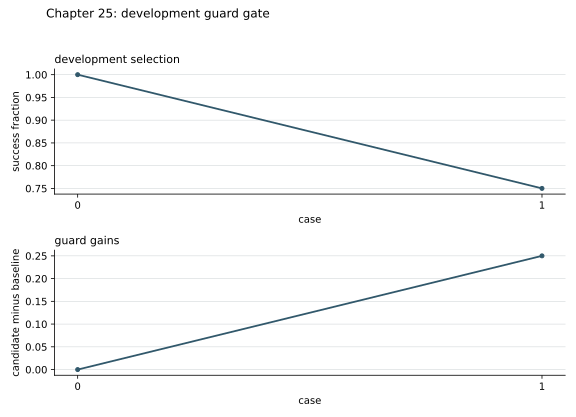

In [3]:
display(SVG(figure_svg(report)))

**Figure 25.L1:** Calculated chapter experiment. Each panel labels its input and output units; interpret it under the assumptions printed in the report.

## Change the assumption

The most direct contamination failure is choosing the candidate with the best guard score instead of the development winner. Another is repeatedly tuning a procedure after every failed guard result while continuing to call the same data untouched. Both make the guard participate in improvement.

The transfer case has a large favorable gain but guard_reused=true. The method rejects a clean release claim because the evidence no longer has its reserved role. The gain remains a descriptive quantity; contamination does not make arithmetic disappear.

A gate can also fail through undefined pairing or a post hoc threshold. Here positions define matched guard tasks, so the caller must preserve that meaning. Choose the threshold before inspecting outcomes and keep candidate, data, and procedure identifiers in the record. Passing this small deterministic rule is not certification of a generally improved agent.

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: constructed changed-assumption example

Calculated quantities:
{
  "selected_candidate": "flashy",
  "selected_guard_gain": 0.25,
  "release_accepted": true,
  "guard_contaminated": false,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate is checked against the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


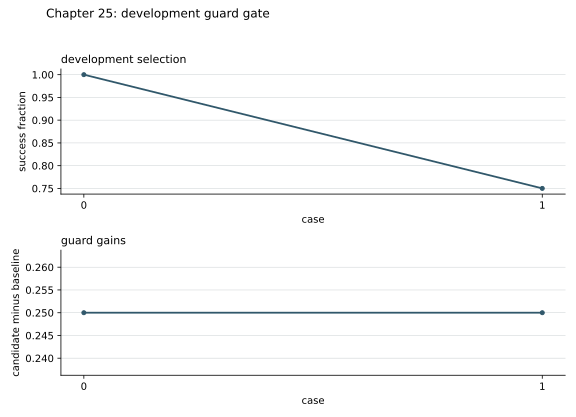

In [4]:
changed_inputs = {'baseline_guard': [True, False, True, False],
 'minimum_guard_gain': 0.2,
 'guard_reused': False,
 'candidates': [{'name': 'flashy',
                 'development': [True, True, True, True],
                 'guard': [True, True, True, False]},
                {'name': 'steady',
                 'development': [True, True, True, False],
                 'guard': [True, True, True, False]}]}
changed = analyze(chapter, changed_inputs)
changed['evidence_kind'] = 'constructed changed-assumption example'
print(report_text(changed))
display(SVG(figure_svg(changed)))

**Figure 25.L2:** The changed-assumption result. Compare the printed quantities and the stated assumptions with the first run. A different input need not imply a causal effect in a deployed agent.

## Try a new case

The transfer proposal has guard success 1 compared with baseline 0.5, for gain 0.5. It exceeds threshold 0.1, but release remains rejected because the guard was reused. This separates favorable observed evidence from a valid acceptance protocol.

For improvement work, freeze the candidate and its runtime before opening guard outcomes. Record the source of every prior evaluation and preserve a genuinely new guard after contamination. If uncertainty control is required, design that statistical rule explicitly rather than assigning a scientific meaning to a convenient numeric threshold. Keep rollback and monitoring outside the claim that the finite gate itself makes deployment safe.

In [5]:
transfer_inputs = {'baseline_guard': [False, True],
 'minimum_guard_gain': 0.1,
 'guard_reused': True,
 'candidates': [{'name': 'proposal', 'development': [True, True], 'guard': [True, True]}]}
transfer = analyze(chapter, transfer_inputs)
transfer['evidence_kind'] = 'constructed transfer example'
print(report_text(transfer))

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: constructed transfer example

Calculated quantities:
{
  "selected_candidate": "proposal",
  "selected_guard_gain": 0.5,
  "release_accepted": false,
  "guard_contaminated": true,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate is checked against the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


## Apply the method to your inputs

The example file below has the exact input shape the method accepts. Copy it to a new file, replace its values, then point `reader_file` at your copy. Run the cell again. Supplied inputs retain their stated provenance; the program cannot establish that they are representative observations.

- **baseline_guard:** Nonempty binary baseline outcomes aligned with each candidate guard.
- **minimum_guard_gain:** Finite prespecified candidate-minus-baseline mean threshold.
- **guard_reused:** Exact boolean stating whether guard evidence influenced improvement or prior selection.
- **candidates:** Nonempty rows with name,development:binary list,guard:binary list matched to baseline_guard.

In [6]:
reader_file = LAB_ROOT / 'data/examples/ch25.json'
reader_inputs = json.loads(reader_file.read_text())
reader_report = analyze(chapter, reader_inputs)
print(report_text(reader_report))

Chapter 25: development-guard-gate
Should the development winner be accepted under a separate release guard?
Evidence: supplied local inputs; provenance not independently verified

Calculated quantities:
{
  "selected_candidate": "proposal",
  "selected_guard_gain": 0.5,
  "release_accepted": false,
  "guard_contaminated": true,
  "baseline_guard_rate": 0.5
}

Interpretation:
Development selects one candidate. Only that frozen candidate is checked against the declared guard threshold, and a reused guard invalidates the clean-release claim.

Assumptions:
- Guard rows are paired with baseline by their position.
- Acceptance threshold is declared before observing guard outcomes.
- Guard is reserved for this single decision.

Limitations:
- Passing a finite gate is not certification or a confidence guarantee.
- Reporting every candidate's guard result requires keeping those results out of future selection.

Execution: completed locally; constructed inputs are not deployment measurements.


## Explore the four chapter demonstrations

The following sections reproduce every demonstration in the illustrated chapter reader. They use the same declared controls, calculation and figure. Begin with the prediction, run the worked case, change one control, then inspect the complete state table. The chapter experiment above remains available for your own compatible inputs.

In [7]:
from math_ai_agents.demos import demo_catalog, demo_states, run_demo, demo_report_text

<a id="demo-c25-d01"></a>

### Demonstration 1: A canary is monitored evidence, and its rules come first

If an accepted version enters a limited release, when does it roll back, and what changes if the rule is chosen after the numbers are seen?

![Equation 25.1](../assets/math/90855c398446144e8c04.svg)

**Symbols and units:** theta is the set of model parameters, frozen, so theta at step t + 1 equals theta at step t. phi_t is the parent version of the procedure: the prompt template, tool-routing rule, memory policy, verifier and retry cap assembled around the model. phi' is the accepted new version, so rollback restores a procedure version, not weights. The cost per period is a constructed resource measure. c is the cost limit (1.00) and the margin is 0.10, so the declared boundary is c minus the margin. An alert is the first period with cost strictly above the boundary.

A canary is a limited release to a declared population, action set, duration and resource budget. Its rollback trigger is set before it starts, here a cost boundary of c minus a margin, together with a named fallback. When the trigger fires the declared fallback applies and the weights were never involved, because Equation (25.1) holds theta fixed. If the boundary is moved after the costs are seen, the same trace can fire late or never.

**Use in this chapter:** Before a canary starts, write the monitoring cadence, population, metric, alert threshold, maximum duration, decision after an alert, and the fallback route. A canary is monitored evidence after acceptance, not a cheap second chance to pass the guard.

**Assumptions:** One constructed cost metric, eight periods, one trigger type. The chapter also names a safety violation, a verifier failure, a decline in a monitored outcome and a missing authority condition as triggers; each needs its own pre-declared rule. A pre-declared boundary protects against moving the rule after the outcomes, but it does not by itself stop leakage through redesign, metric changes or holdout peeking, and a valid sequential procedure is a separate matter.

**Predict before running:** Take the creeping-cost trace under the rule declared first. In which period does the alert fire? Then switch to the rule chosen after looking.

**Controls you can change:**

- **Cost trace during the canary:** `trace` accepts 'steady', 'creeping', 'spike'.
- **When the boundary was set:** `rule` accepts 'declared', 'after'.
- **Fallback named in advance:** `fallback` accepts 'restore', 'hold'.

**Source section:** Acceptance is a constrained release decision.

**Evidence:** constructed teaching example.

Constructed example: canary cost traces, an eight-period duration and a cost limit with margin defined for this reader around the chapter's rollback and monitoring rules.

Prediction choices:

1. Period 3
2. Period 5
3. Period 8
4. No alert

**Boundary of the conclusion:** Training-time model updates are a separate question. This chapter held theta fixed; changing it involves its own training and evaluation controls, not covered here.

**Common wrong turn:** The chapter notes that the Reflexion paper calls its method verbal reinforcement learning but does not report a model silently rewriting its weights after every failure. A reflection is text added to memory. The versioned object is the procedure, so theta at step t + 1 equals theta at step t and rollback restores the parent procedure phi_t.

A canary is monitored evidence, and its rules come first
Controls: {"trace": "creeping", "rule": "declared", "fallback": "restore"}
Evidence: constructed teaching example

Calculated quantities:
Boundary used: 0.90 (declared before the canary)
Alert under the declared 0.90: period 5
Alert under the boundary used: period 5
Periods under phi': 5 of 8
Fallback after an alert: restore phi_t
Model parameters changed: 0 (theta stays frozen)

Worked steps:
1. Boundary fixed before period 1: c - margin = 1.00 - 0.10 = 0.90.
2. Observed cost per period: 0.80, 0.83, 0.86, 0.89, 0.92, 0.95, 0.98, 1.01.
3. First period above 0.90: period 5 with cost 0.92.
4. The alert fires in period 5; the declared fallback is restore the parent version phi_t.
5. theta at step t + 1 equals theta at step t in every period, so rollback only changes the procedure version.

Boundary = c - margin = 1.00 - 0.10 = 0.90, fixed before period 1. Costs run 0.80, 0.83, 0.86, 0.89, 0.92; the first above 0.90 is period 5 (0.92

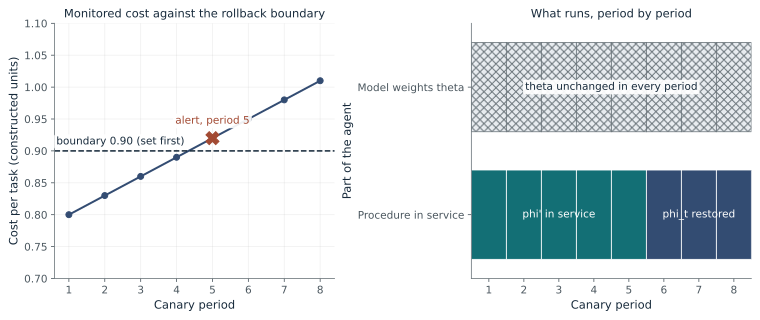

In [8]:
demo_id = 'C25-D01'
demo_controls = {'trace': 'creeping', 'rule': 'declared', 'fallback': 'restore'}
demo_result = run_demo(25, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Cost trace during the canary** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

A canary is monitored evidence, and its rules come first
Controls: {"trace": "steady", "rule": "declared", "fallback": "restore"}
Evidence: constructed teaching example

Calculated quantities:
Boundary used: 0.90 (declared before the canary)
Alert under the declared 0.90: none
Alert under the boundary used: none
Periods under phi': 8 of 8
Fallback after an alert: restore phi_t
Model parameters changed: 0 (theta stays frozen)

Worked steps:
1. Boundary fixed before period 1: c - margin = 1.00 - 0.10 = 0.90.
2. Observed cost per period: 0.80, 0.82, 0.81, 0.83, 0.82, 0.84, 0.83, 0.82.
3. No period is above 0.90; the highest cost is 0.84.
4. No alert, so the canary ends at its maximum duration of 8 periods and the decision stays with the owner.
5. theta at step t + 1 equals theta at step t in every period, so rollback only changes the procedure version.

Boundary = c - margin = 1.00 - 0.10 = 0.90, fixed before period 1. Costs run 0.80, 0.82, 0.81, 0.83, 0.82, 0.84, 0.83, 0.82, and the high

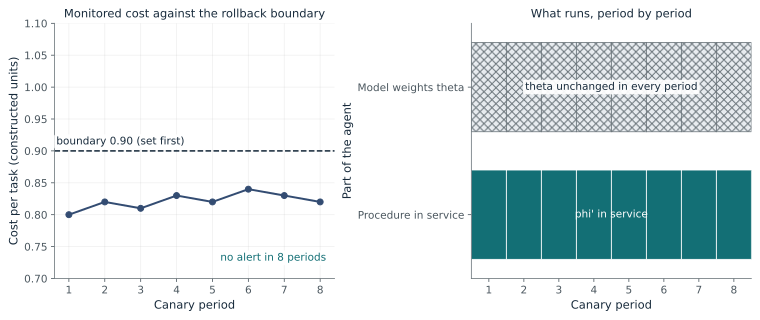

In [9]:
changed_controls = {'trace': 'steady', 'rule': 'declared', 'fallback': 'restore'}
changed_demo = run_demo(25, 'C25-D01', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [10]:
state_rows = []
for controls in demo_states(25, 'C25-D01'):
    state = run_demo(25, 'C25-D01', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "trace": "steady",
      "rule": "declared",
      "fallback": "restore"
    },
    "metrics": [
      [
        "Boundary used",
        "0.90 (declared before the canary)"
      ],
      [
        "Alert under the declared 0.90",
        "none"
      ],
      [
        "Alert under the boundary used",
        "none"
      ],
      [
        "Periods under phi'",
        "8 of 8"
      ],
      [
        "Fallback after an alert",
        "restore phi_t"
      ],
      [
        "Model parameters changed",
        "0 (theta stays frozen)"
      ]
    ]
  },
  {
    "controls": {
      "trace": "steady",
      "rule": "declared",
      "fallback": "hold"
    },
    "metrics": [
      [
        "Boundary used",
        "0.90 (declared before the canary)"
      ],
      [
        "Alert under the declared 0.90",
        "none"
      ],
      [
        "Alert under the boundary used",
        "none"
      ],
      [
        "Periods under phi'",
        "8 of

**Check your understanding:** A canary declares its boundary as c - margin with c = 1.20 and margin 0.15. Costs by period are 1.00, 1.05, 1.08 and 1.12. In which period does the alert fire, and what happens if the boundary had been moved to c after looking?

[Answer and worked reasoning](../solutions/ch25.md#demonstration-1). [Matching browser demonstration](../readers/25-development-guard-gate/reader.html#C25-D01).

<a id="demo-c25-d02"></a>

### Demonstration 2: Development chooses, the guard checks one frozen pick

Once development has picked a winner, what does a separate guard set decide, and what breaks if the guard picks or is reused?

![Equation 25.2](../assets/math/2ff671a2b70bfaa5ac25.svg)

**Symbols and units:** D is the development set and G the guard set. V-hat_D(phi) is a procedure's estimated success on D, and Delta-hat_D(phi_j) is candidate j's development uplift over the parent phi_t. The arg max picks the winner phi'. For guard case i, Z_i is the candidate's result minus the parent's, between -1 and 1 (here +1, 0 or -1), and Delta-hat_G is the average of Z_i over the m guard cases. The threshold is the smallest guard gain accepted. The candidates are named flashy and steady (and proposal in the transfer case); the names are labels only.

Development picks the candidate with the best development score. Only that frozen candidate is then compared with the parent on guard cases, case by case, and the average of the differences Z is its guard gain. The other candidate may look better on the guard, but letting the guard choose would make the guard part of selection, so its best-of-several score stops being a test. If the guard was already reused, the gate rejects regardless of the gain.

**Use in this chapter:** Write down which candidate is frozen, and the threshold, before anyone opens guard outcomes. Report guard numbers for the frozen candidate only, and treat any guard that has informed a redesign as development data.

**Assumptions:** Two or four paired cases with binary outcomes, as in the laboratory's teaching cases, so the gain can only be a multiple of 0.25 or 0.5 and the gate is a teaching device. A threshold is a rule, not a confidence statement. The reuse flag records what you declare, not the true history, and the threshold is only meaningful if fixed before guard access. A tie in guard gain leaves the development pick in place.

**Predict before running:** In the laboratory's default case with a clean guard, threshold 0.20 and the development winner tested, which candidate is frozen and what happens?

**Controls you can change:**

- **Teaching case:** `case` accepts 'default', 'changed', 'transfer'.
- **Guard history:** `guard` accepts 'clean', 'reused'.
- **Who picks the candidate to test:** `chooser` accepts 'development', 'guard'.

**Source section:** Development can choose a candidate; it cannot certify one.

**Evidence:** constructed teaching example.

Constructed example: the laboratory's default, changed and transfer teaching cases, computed with its own gate function.

Prediction choices:

1. Flashy is frozen and fails the guard (gain 0.00)
2. Flashy is frozen and passes the guard
3. Steady is frozen and passes the guard (gain 0.25)

**Boundary of the conclusion:** The chapter does not promise a clean separation between procedure and environment. A new tool, memory store, evaluator or task distribution can change the assembled system in ways that demand fresh evaluation.

**Common wrong turn:** The chapter says the problem is selection, not bad faith: if several changes have no true benefit, random variation can still place one at the top of the table. The winning development result records both the candidate and the selection process that chose it, so it cannot also serve as untouched evidence for that candidate.

Development chooses, the guard checks one frozen pick
Controls: {"case": "default", "guard": "clean", "chooser": "development"}
Evidence: constructed teaching example

Calculated quantities:
Development rates: flashy 1.00, steady 0.75
Selected on development: flashy
Candidate tested on the guard: flashy
Guard cases m: 4
Guard gain of the tested candidate: 0.00
Threshold: 0.20
Guard status: clean (used once)
Release decision: rejected (gain below threshold)

Worked steps:
1. Development rates: flashy 4/4 = 1.00, steady 3/4 = 0.75.
2. Development picks flashy and it is frozen.
3. Paired guard differences Z (candidate minus parent), case by case: 0 + 0 + 0 + 0.
4. Guard gain = (0 + 0 + 0 + 0) / 4 = 0.00.
5. Threshold 0.20 is fixed before guard access; 0.00 is below it.
6. Guard status: clean, used once. Release: rejected (gain below threshold).

Development rates: flashy 4/4 = 1.00, steady 3/4 = 0.75; the highest is flashy. Its paired guard differences (candidate minus parent) are 0 + 0 +

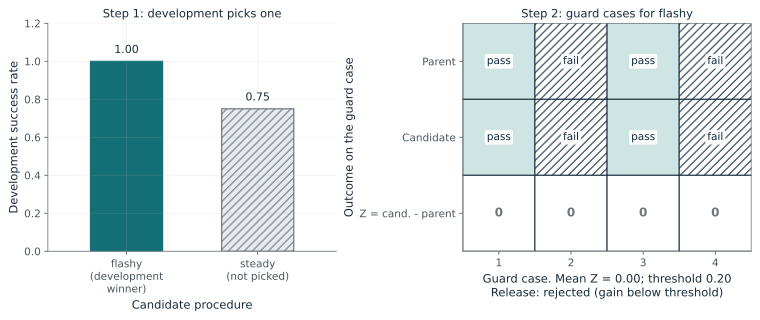

In [11]:
demo_id = 'C25-D02'
demo_controls = {'case': 'default', 'guard': 'clean', 'chooser': 'development'}
demo_result = run_demo(25, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Teaching case** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Development chooses, the guard checks one frozen pick
Controls: {"case": "changed", "guard": "clean", "chooser": "development"}
Evidence: constructed teaching example

Calculated quantities:
Development rates: flashy 1.00, steady 0.75
Selected on development: flashy
Candidate tested on the guard: flashy
Guard cases m: 4
Guard gain of the tested candidate: 0.25
Threshold: 0.20
Guard status: clean (used once)
Release decision: accepted by this gate

Worked steps:
1. Development rates: flashy 4/4 = 1.00, steady 3/4 = 0.75.
2. Development picks flashy and it is frozen.
3. Paired guard differences Z (candidate minus parent), case by case: 0 + 1 + 0 + 0.
4. Guard gain = (0 + 1 + 0 + 0) / 4 = 0.25.
5. Threshold 0.20 is fixed before guard access; 0.25 is at least it.
6. Guard status: clean, used once. Release: accepted by this gate.

Development rates: flashy 4/4 = 1.00, steady 3/4 = 0.75; the highest is flashy. Its paired guard differences (candidate minus parent) are 0 + 1 + 0 + 0, so guard 

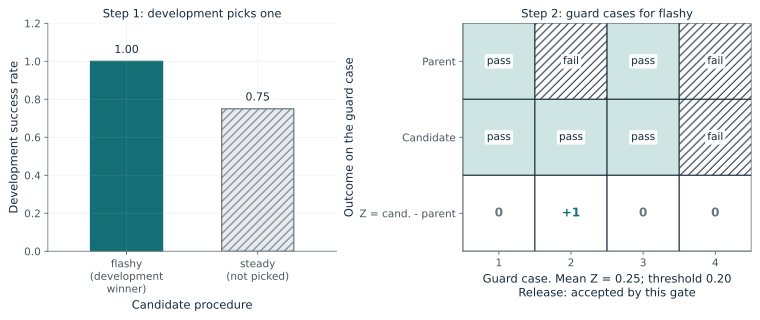

In [12]:
changed_controls = {'case': 'changed', 'guard': 'clean', 'chooser': 'development'}
changed_demo = run_demo(25, 'C25-D02', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [13]:
state_rows = []
for controls in demo_states(25, 'C25-D02'):
    state = run_demo(25, 'C25-D02', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "case": "default",
      "guard": "clean",
      "chooser": "development"
    },
    "metrics": [
      [
        "Development rates",
        "flashy 1.00, steady 0.75"
      ],
      [
        "Selected on development",
        "flashy"
      ],
      [
        "Candidate tested on the guard",
        "flashy"
      ],
      [
        "Guard cases m",
        "4"
      ],
      [
        "Guard gain of the tested candidate",
        "0.00"
      ],
      [
        "Threshold",
        "0.20"
      ],
      [
        "Guard status",
        "clean (used once)"
      ],
      [
        "Release decision",
        "rejected (gain below threshold)"
      ]
    ]
  },
  {
    "controls": {
      "case": "default",
      "guard": "clean",
      "chooser": "guard"
    },
    "metrics": [
      [
        "Development rates",
        "flashy 1.00, steady 0.75"
      ],
      [
        "Selected on development",
        "flashy"
      ],
      [
        "Candidate

**Check your understanding:** A frozen candidate beats its parent on 2 of 8 guard cases, loses on 1 and ties on 5. Its threshold is 0.20. Does it pass a clean guard?

[Answer and worked reasoning](../solutions/ch25.md#demonstration-2). [Matching browser demonstration](../readers/25-development-guard-gate/reader.html#C25-D02).

<a id="demo-c25-d03"></a>

### Demonstration 3: How little a guard promises, and how it wears out

How likely is a candidate with no true benefit to clear a guard threshold, and which guard decisions does that number still cover after a guard result reaches the designer?

![Equation 25.3](../assets/math/1e15d3b9f1d8013a77bc.svg)

**Symbols and units:** m is the number of guard cases. Each paired difference Z_i lies between -1 and 1 and has true mean Delta, which is at most 0 for a candidate with no benefit. Delta-hat_G is the guard average. The threshold tau is 0.25, as in the chapter. exp(x) is e raised to the power x. The decision count q is how many separately fixed candidates use the guard, each added once. In the redesign states the second guard result is shown to the designer, who revises the third candidate.

The bound exp(-m x 0.25^2 / 2) shrinks quickly as guard cases are added. For several candidates, each fixed before it meets the guard, the chances add up, so ten decisions cost ten times the single bound. The exact tail for one concrete no-benefit guard lies below the bound, which is a worst-case guarantee, not a prediction. Once a guard result changes the next candidate, that candidate was not fixed before guard access and the adding-up no longer applies.

**Use in this chapter:** Set a guard query budget before use. Count how many candidates will be tested, size the guard so the total stays small, and retire the guard for release evidence once its results start steering redesign. Track who has seen which outcomes, not whether the bank file changed.

**Assumptions:** The chapter's constructed conditions: every counted candidate is fixed before guard access, outcomes lie in [-1, 1], and outcomes are independent across cases. Shared tool state or a common evaluator can break independence. The exact tail uses one convenient distribution, plus or minus 1 with equal chance; it is not a real agent. The guard is evidence for one version, one task population and one evaluation protocol, and a shift in the task distribution changes what a clean result describes.

**Predict before running:** At 200 guard cases and 10 decisions the total is 0.0193. Switch to the state where guard result 2 reaches the designer. What happens to the total, and what happens to decisions 3 to 10?

**Controls you can change:**

- **Number of guard cases m:** `guard_cases` accepts 50, 200, 400.
- **Candidates tested on the guard:** `decisions` accepts 3, 10.
- **Did a guard result reach the designer?:** `redesign` accepts 'never', 'after2'.

**Source section:** A guard becomes development evidence when it is consulted repeatedly.

**Evidence:** constructed teaching example.

Constructed example: the chapter's own 200-case, 0.25 threshold, ten-decision values and its three-query ledger, with other sizes and the redesign state defined for this reader.

Prediction choices:

1. The total rises, because more decisions are added
2. The total falls to 2 x 0.00193 but decisions 3 to 10 get no bound
3. The total stays at 0.0193

**Common wrong turn:** The chapter says the word frozen describes access, not a file format. A test bank on a server still becomes development evidence if operators learn which changes passed it and redesign from that information.

How little a guard promises, and how it wears out
Controls: {"guard_cases": 200, "decisions": 10, "redesign": "never"}
Evidence: constructed teaching example

Calculated quantities:
Guard cases m: 200
Bound, one decision: 0.00193
Decisions fixed before guard access: 10 of 10
Total bound over those decisions: 0.0193
Decisions needing a fresh guard: 0
Exact tail, fair plus or minus 1 case: 0.000250
Bound divided by exact tail: 7.7

Worked steps:
1. Exponent = m x tau^2 / 2 = 200 x 0.0625 / 2 = 6.250.
2. Bound for one fixed candidate: exp(-6.250) = 0.00193.
3. Decisions fixed before any guard access: 10 of 10.
4. Total over those decisions: 10 x 0.00193 = 0.0193.
5. No guard result reached a designer, so no decision needs a new guard.
6. Exact tail for one fair plus or minus 1 guard: 0.000250, below the bound 0.00193.

Exponent = m x tau^2 / 2 = 200 x 0.0625 / 2 = 6.250, so the bound is exp(-6.250) = 0.00193. Over the 10 decisions fixed before any guard access the total is at most 10 x 0.

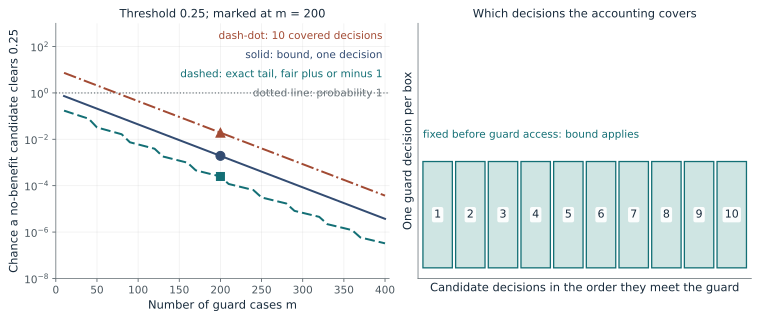

In [14]:
demo_id = 'C25-D03'
demo_controls = {'guard_cases': 200, 'decisions': 10, 'redesign': 'never'}
demo_result = run_demo(25, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Number of guard cases m** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

How little a guard promises, and how it wears out
Controls: {"guard_cases": 50, "decisions": 10, "redesign": "never"}
Evidence: constructed teaching example

Calculated quantities:
Guard cases m: 50
Bound, one decision: 0.210
Decisions fixed before guard access: 10 of 10
Total bound over those decisions: 2.10 (above 1, says nothing)
Decisions needing a fresh guard: 0
Exact tail, fair plus or minus 1 case: 0.0325
Bound divided by exact tail: 6.5

Worked steps:
1. Exponent = m x tau^2 / 2 = 50 x 0.0625 / 2 = 1.562.
2. Bound for one fixed candidate: exp(-1.562) = 0.210.
3. Decisions fixed before any guard access: 10 of 10.
4. Total over those decisions: 10 x 0.210 = 2.10 (above 1, says nothing).
5. No guard result reached a designer, so no decision needs a new guard.
6. Exact tail for one fair plus or minus 1 guard: 0.0325, below the bound 0.210.

Exponent = m x tau^2 / 2 = 50 x 0.0625 / 2 = 1.562, so the bound is exp(-1.562) = 0.210. The total 2.10 over the 10 covered decisions is above 

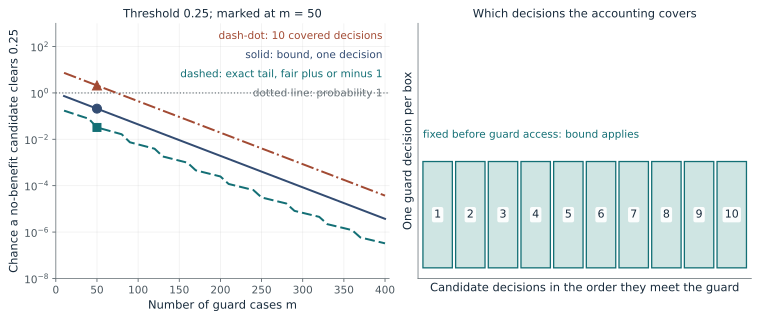

In [15]:
changed_controls = {'guard_cases': 50, 'decisions': 10, 'redesign': 'never'}
changed_demo = run_demo(25, 'C25-D03', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [16]:
state_rows = []
for controls in demo_states(25, 'C25-D03'):
    state = run_demo(25, 'C25-D03', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "guard_cases": 50,
      "decisions": 3,
      "redesign": "never"
    },
    "metrics": [
      [
        "Guard cases m",
        "50"
      ],
      [
        "Bound, one decision",
        "0.210"
      ],
      [
        "Decisions fixed before guard access",
        "3 of 3"
      ],
      [
        "Total bound over those decisions",
        "0.629"
      ],
      [
        "Decisions needing a fresh guard",
        "0"
      ],
      [
        "Exact tail, fair plus or minus 1 case",
        "0.0325"
      ],
      [
        "Bound divided by exact tail",
        "6.5"
      ]
    ]
  },
  {
    "controls": {
      "guard_cases": 50,
      "decisions": 3,
      "redesign": "after2"
    },
    "metrics": [
      [
        "Guard cases m",
        "50"
      ],
      [
        "Bound, one decision",
        "0.210"
      ],
      [
        "Decisions fixed before guard access",
        "2 of 3"
      ],
      [
        "Total bound over those decisio

**Check your understanding:** With m = 300 guard cases and threshold 0.25, what is the bound for one decision?

[Answer and worked reasoning](../solutions/ch25.md#demonstration-3). [Matching browser demonstration](../readers/25-development-guard-gate/reader.html#C25-D03).

<a id="demo-c25-d04"></a>

### Demonstration 4: Acceptance needs four passes, not a high score

Can a large guard uplift make up for a cost that is over the limit, a missing permission or an untested rollback?

![Equation 25.4](../assets/math/ee5d22fff351da35d73c.svg)

**Symbols and units:** phi' is the candidate version. Delta-hat_G is its guard uplift and tau the required uplift (0.25). C-hat_G is its guard cost estimate, c the current cost limit (1.00) and epsilon_safe the reserved margin (0.10). Authorized is 1 if the version is permitted in the proposed canary scope and 0 otherwise (a canary is a small monitored release). Rollback is 1 if a tested path back to the parent version exists and 0 otherwise.

Equation (25.4) turns each condition into a pass or fail, then requires all four. Cost is held to c minus a margin, so a cost of 0.95 fails even though it is under c. The conditions multiply instead of adding, so a zero anywhere gives zero overall, however large the uplift. Authority and rollback are yes or no, not scores that can be traded against performance.

**Use in this chapter:** Write a release record with four lines: uplift against its threshold, cost against its limit minus margin, the named authority holder and scope, and the tested rollback route. Name the owner for each, for example the workflow owner for the guard result and the incident owner for rollback alerts. A missing line blocks release.

**Assumptions:** Constructed values for one candidate, with uplift and cost already estimated on a clean guard (see Demonstration 3 for what that requires). The laboratory's gate in Demonstration 2 checks only the uplift threshold and the reuse flag, so cost, authority and rollback are computed directly here. A passing record permits a limited canary; it does not show that the change is safe at scale.

**Predict before running:** With uplift 0.45 and everything else passing, switch to cost 0.95. That is under the limit c = 1.00. Is the version accepted?

**Controls you can change:**

- **Guard uplift estimate:** `uplift` accepts 0.2, 0.25, 0.45.
- **Cost, authority and rollback:** `others` accepts 'all', 'cost', 'authority', 'rollback'.

**Source section:** Acceptance is a constrained release decision.

**Evidence:** constructed teaching example.

Constructed example: the chapter's threshold 0.25 with cost limit, margin and candidate values defined for this reader; the authority case follows the workbench's revised third candidate.

Prediction choices:

1. Yes, 0.95 is under c = 1.00
2. No, 0.95 is above c - margin = 0.90

**Boundary of the conclusion:** An accepted procedure may later generate a new candidate. That does not convert the system into a source of guaranteed recursive gains. A positive result for phi' does not prove that phi'' will improve, and it does not license the system to expand its own change family or authority envelope.

**Common wrong turn:** The chapter says the four conditions are not four terms of a score to be traded against one another. A procedure that improves a score but lacks permission to call a tool or lacks a recovery route is not accepted.

Acceptance needs four passes, not a high score
Controls: {"uplift": 0.45, "others": "all"}
Evidence: constructed teaching example

Calculated quantities:
1. Uplift condition: pass (0.45 vs 0.25)
2. Cost condition: pass (0.80 vs 0.90)
3. Authorized in scope: pass
4. Rollback path tested: pass
Accept: yes (1)

Worked steps:
1. Cost limit with margin: c - margin = 1.00 - 0.10 = 0.90.
2. Uplift: 0.45 is at least tau = 0.25, so condition 1 = 1.
3. Cost: 0.80 is at most 0.90, so condition 2 = 1.
4. Authority for this scope = 1; tested rollback path = 1.
5. accept = 1 x 1 x 1 x 1 = 1; the conditions multiply, so one zero decides.

Limit = c - margin = 1.00 - 0.10 = 0.90. Conditions: uplift 0.45 against 0.25 gives 1; cost 0.80 against the limit 0.90 gives 1; authorized gives 1; rollback gives 1. accept = 1 x 1 x 1 x 1 = 1. All four conditions hold, so the version may enter the limited canary of Demonstration 1. Acceptance permits that monitored release; it does not show the change is safe at s

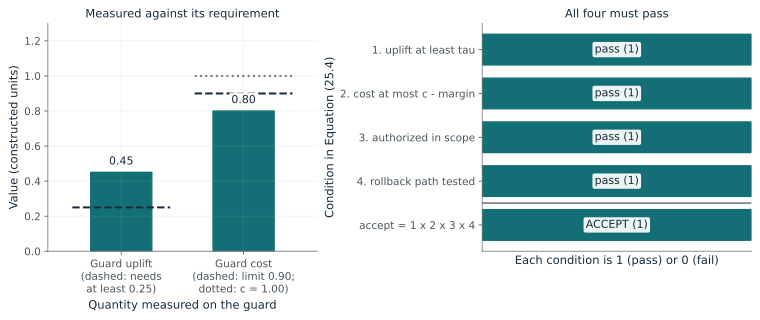

In [17]:
demo_id = 'C25-D04'
demo_controls = {'uplift': 0.45, 'others': 'all'}
demo_result = run_demo(25, demo_id, demo_controls)
print(demo_report_text(demo_result))
display(SVG(demo_result['figure_svg']))

Change only **Guard uplift estimate** below. Predict which quantity and part of the figure should change. Keep the other inputs fixed so the comparison has a clear meaning.

Acceptance needs four passes, not a high score
Controls: {"uplift": 0.2, "others": "all"}
Evidence: constructed teaching example

Calculated quantities:
1. Uplift condition: fail (0.20 vs 0.25)
2. Cost condition: pass (0.80 vs 0.90)
3. Authorized in scope: pass
4. Rollback path tested: pass
Accept: no (0)

Worked steps:
1. Cost limit with margin: c - margin = 1.00 - 0.10 = 0.90.
2. Uplift: 0.20 is below tau = 0.25, so condition 1 = 0.
3. Cost: 0.80 is at most 0.90, so condition 2 = 1.
4. Authority for this scope = 1; tested rollback path = 1.
5. accept = 0 x 1 x 1 x 1 = 0; the conditions multiply, so one zero decides.

Limit = c - margin = 1.00 - 0.10 = 0.90. Conditions: uplift 0.20 against 0.25 gives 0; cost 0.80 against the limit 0.90 gives 1; authorized gives 1; rollback gives 1. accept = 0 x 1 x 1 x 1 = 0. Rejected because uplift 0.20 is below 0.25. No strong condition can pay for a failed one.

Assumptions: Constructed values for one candidate, with uplift and cost already estimat

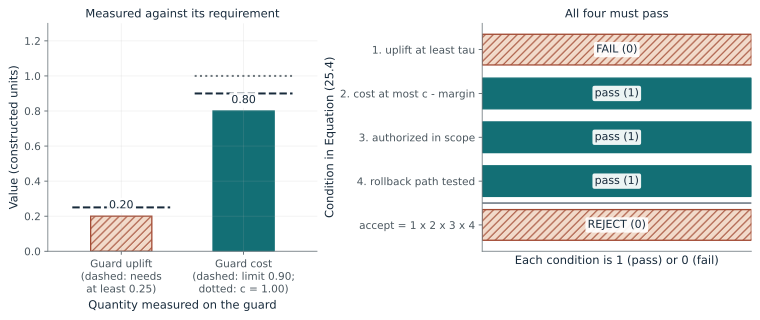

In [18]:
changed_controls = {'uplift': 0.2, 'others': 'all'}
changed_demo = run_demo(25, 'C25-D04', changed_controls)
print(demo_report_text(changed_demo))
display(SVG(changed_demo['figure_svg']))

The complete table below reruns every selectable state in the web demonstration. Each row contains the controls and calculated quantities. It establishes coverage; the separate analytical tests check whether those quantities are mathematically correct.

In [19]:
state_rows = []
for controls in demo_states(25, 'C25-D04'):
    state = run_demo(25, 'C25-D04', controls, include_figure=False)
    state_rows.append({'controls': controls, 'metrics': state['metrics']})
print(json.dumps(state_rows, indent=2, ensure_ascii=False))

[
  {
    "controls": {
      "uplift": 0.2,
      "others": "all"
    },
    "metrics": [
      [
        "1. Uplift condition",
        "fail (0.20 vs 0.25)"
      ],
      [
        "2. Cost condition",
        "pass (0.80 vs 0.90)"
      ],
      [
        "3. Authorized in scope",
        "pass"
      ],
      [
        "4. Rollback path tested",
        "pass"
      ],
      [
        "Accept",
        "no (0)"
      ]
    ]
  },
  {
    "controls": {
      "uplift": 0.2,
      "others": "cost"
    },
    "metrics": [
      [
        "1. Uplift condition",
        "fail (0.20 vs 0.25)"
      ],
      [
        "2. Cost condition",
        "fail (0.95 vs 0.90)"
      ],
      [
        "3. Authorized in scope",
        "pass"
      ],
      [
        "4. Rollback path tested",
        "pass"
      ],
      [
        "Accept",
        "no (0)"
      ]
    ]
  },
  {
    "controls": {
      "uplift": 0.2,
      "others": "authority"
    },
    "metrics": [
      [
        "1. Uplift

**Check your understanding:** A candidate has uplift 0.40, cost 0.92, authority granted and rollback tested, with c = 1.00 and margin 0.10. Is it accepted?

[Answer and worked reasoning](../solutions/ch25.md#demonstration-4). [Matching browser demonstration](../readers/25-development-guard-gate/reader.html#C25-D04).

## Questions

1. Why not release steady by default?

2. What changed gain allows flashy to pass?

3. Does contamination erase observed gain?

Answers: [separate solutions](../solutions/ch25.md). Try the calculation before opening them.

## Summary

Development chooses the procedure; reserved guard evidence checks the frozen choice. The default winner fails, the changed winner passes a finite threshold, and the transfer gain cannot support clean acceptance after reuse. These distinctions prevent adaptation from masquerading as independent validation. The gate is an inspectable protocol under declared pairing and history, not certification. Preserve data roles, thresholds, and candidate identity before making a release claim.

Limits of this experiment:

- This is a local calculation under declared inputs, not an empirical claim about a deployed agent.
- Read the returned assumptions and limitations before applying the numerical result.

The assistant skill is [`maa-25-development-guard-gate`](../skills/maa-25-development-guard-gate/SKILL.md). It uses this notebook's tested computation and input contract.

## Equations from the chapter

These are the unchanged display equations and their explanations from the canonical chapter. They are a reference for the experiment, not a claim that every equation is numerically implemented by this one method.

### Equation 25.1

![Equation 25.1](../assets/math/90855c398446144e8c04.svg)

Names a proposed procedure version while keeping the underlying model parameters frozen.

`e_t` can lead to a change in `\phi`; it does not make a claim about a new value of `\theta`.

LaTeX source, preserved for inspection:

```latex
\phi'\in\mathcal M(\phi_t,e_t), \qquad
\theta_{t+1}=\theta_t.
\tag{25.1}
```

### Equation 25.2

![Equation 25.2](../assets/math/2ff671a2b70bfaa5ac25.svg)

Selects a development candidate, then defines its paired guard estimate.

Development chooses `\phi'`; the guard averages bounded parent-candidate differences after that choice is fixed.

LaTeX source, preserved for inspection:

```latex
\begin{aligned}
&\widehat\Delta_D(\phi_j)=\widehat V_D(\phi_j)-\widehat V_D(\phi_t),
\qquad \phi'=\arg\max_{\phi_j\in\Phi_t}\widehat\Delta_D(\phi_j),\\
&Z_i(\phi')\in[-1,1], \qquad
\widehat\Delta_G(\phi')=\frac{1}{m}\sum_{i=1}^{m}Z_i(\phi').
\end{aligned}
\tag{25.2}
```

### Equation 25.3

![Equation 25.3](../assets/math/1e15d3b9f1d8013a77bc.svg)

Bounds one fixed candidate's false acceptance and shows the stated ten-decision scale.

Both values depend on the frozen-candidate, bounded-outcome, and independent-guard assumptions.

LaTeX source, preserved for inspection:

```latex
\Pr\!\left(\widehat\Delta_G(\phi')\geq 0.25\right) \leq
\exp\!\left(-\frac{200(0.25)^2}{2}\right) \approx 0.00193
\quad\text{for every fixed }\phi'\text{ with }\Delta(\phi')\leq0,
\qquad 10(0.00193)\approx0.0193.
\tag{25.3}
```

### Equation 25.4

![Equation 25.4](../assets/math/ee5d22fff351da35d73c.svg)

Admits a procedure version only when uplift, cost, authority, and rollback each pass their own test.

A high uplift cannot compensate for missing authority or an untested return path.

LaTeX source, preserved for inspection:

```latex
\operatorname{accept}(\phi')=1 \iff \begin{cases}
\widehat\Delta_G(\phi')\geq\tau,\\
\widehat C_G(\phi')\leq c-\varepsilon_{\mathrm{safe}},\\
\operatorname{Authorized}_{\mathcal G}(\phi')=1,\\
\operatorname{Rollback}(\phi',\phi_t)=1.
\end{cases}
\tag{25.4}
```